# Transition summaries

This notebook is intentionally concise:
- mean summaries only
- rotated 45 degree sectors instead of the old sign quadrants
- one figure style reused for `act`, `post/familiar`, and `post/novel`

In [16]:
from pathlib import Path

import context_contrasting.data_analysis.transitions_helpers as th

build_mean_summary = th.build_mean_summary
DEFAULT_PLOT_STYLE = th.DEFAULT_PLOT_STYLE
compute_response_limits = th.compute_response_limits
compute_shift_limits = th.compute_shift_limits
load_transition_table = th.load_transition_table
plot_mean_transition_summary = th.plot_mean_transition_summary
sector_fraction_table = th.sector_fraction_table

PLOT_STYLE = DEFAULT_PLOT_STYLE | {
    "pre_point_alpha": 1.0,
    "target_point_alpha": 0.8,
    "shift_point_alpha": 1.0,
    "pre_vector_alpha": 0.5,
    "target_vector_alpha": 0.5,
    "individual_vector_width": 0.005,
    "mean_arrow_width": 3.1,
    "mean_arrow_mutation_scale": 16.5,
}

DATA_DIR = Path("context_contrasting/data_analysis")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

act_table = load_transition_table(DATA_DIR / "transitions_act.csv")
post_table = load_transition_table(DATA_DIR / "transitions_post.csv")

act_mean = build_mean_summary(act_table, image_group="all", pre_stage="Pre", target_stage="Task")
post_familiar_mean = build_mean_summary(post_table, image_group="familiar", pre_stage="Pre", target_stage="Post")
post_novel_mean = build_mean_summary(post_table, image_group="novel", pre_stage="Pre", target_stage="Post")

post_response_lims = compute_response_limits(post_familiar_mean, post_novel_mean)
post_shift_lims = compute_shift_limits(post_familiar_mean, post_novel_mean)


## Act mean


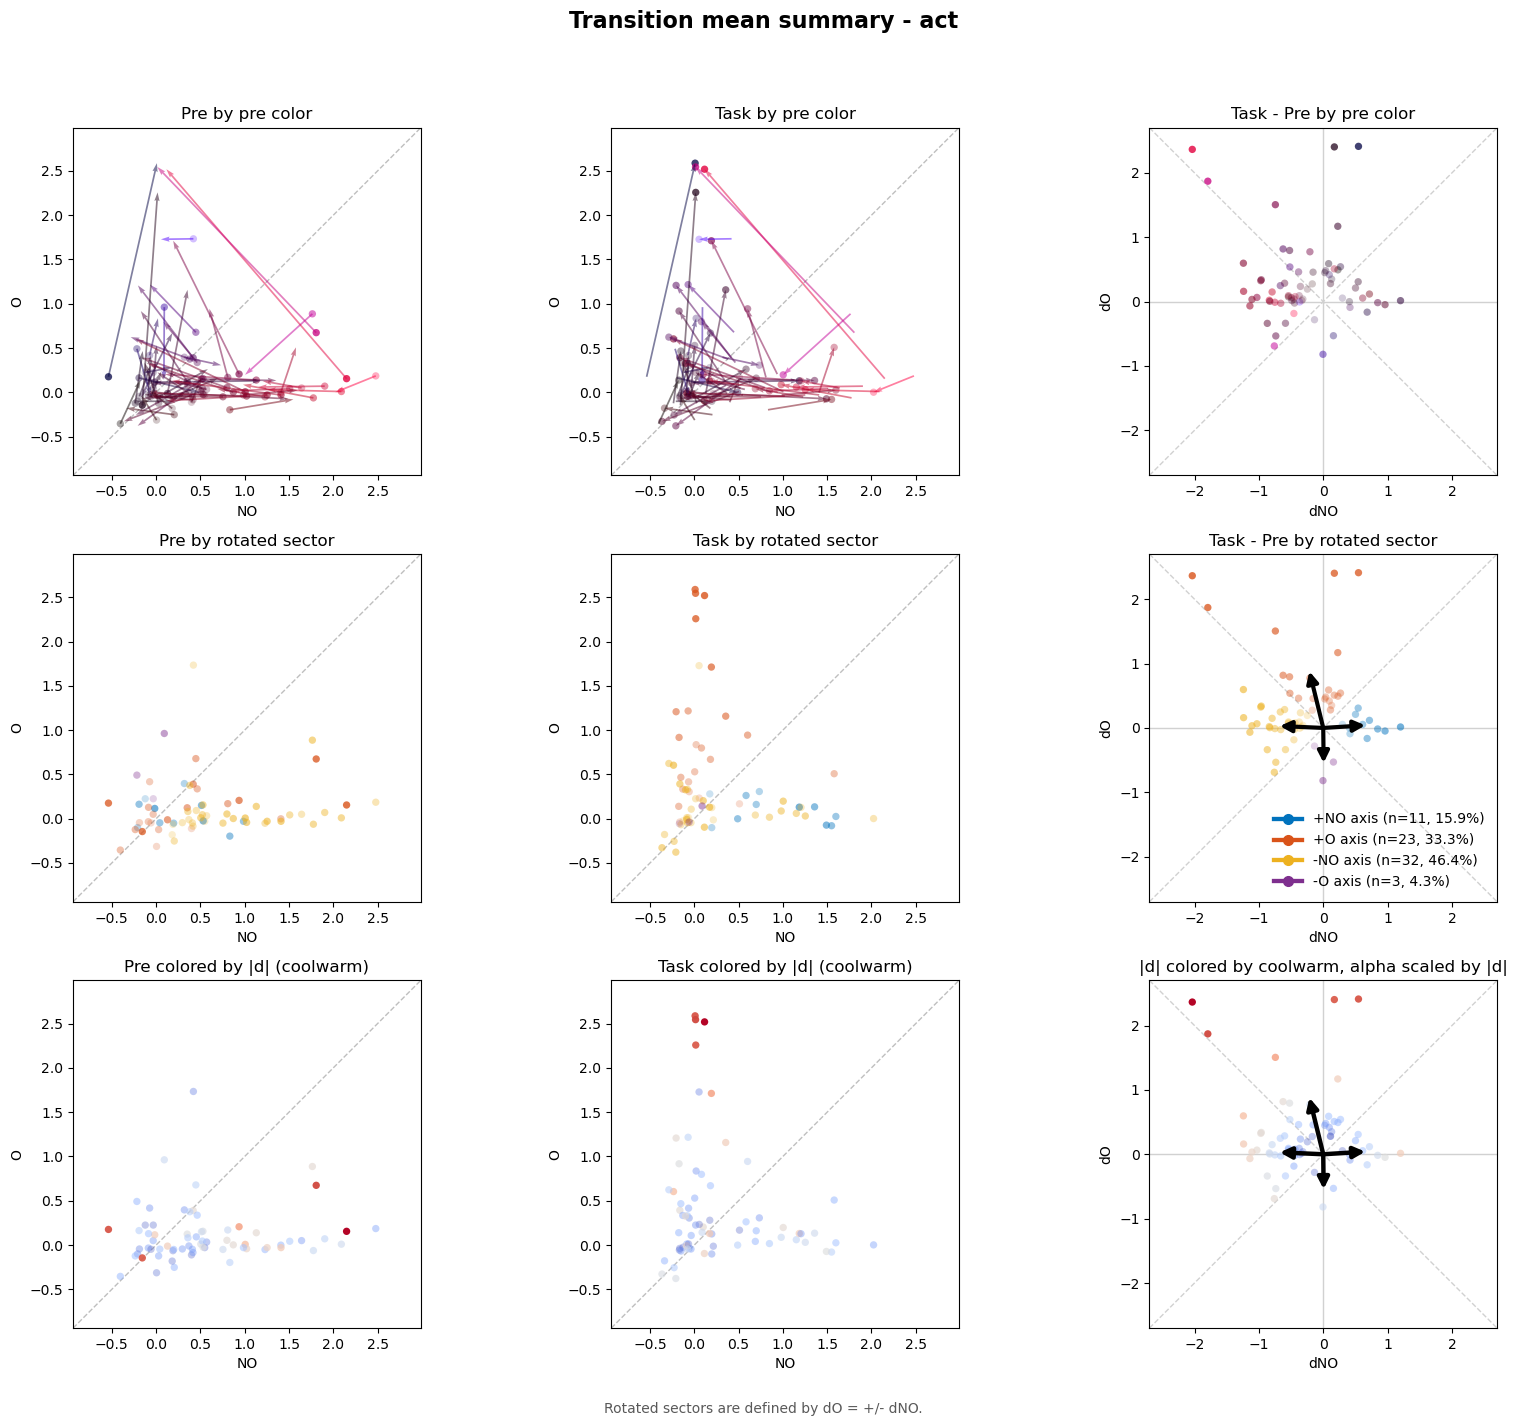

In [17]:
act_mean = act_mean.loc[act_mean['dNorm'] > 0.3]

_ = plot_mean_transition_summary(
    act_mean,
    title="Transition mean summary - act",
    start_label="Pre",
    end_label="Task",
    style=PLOT_STYLE,
)


## Post mean: familiar


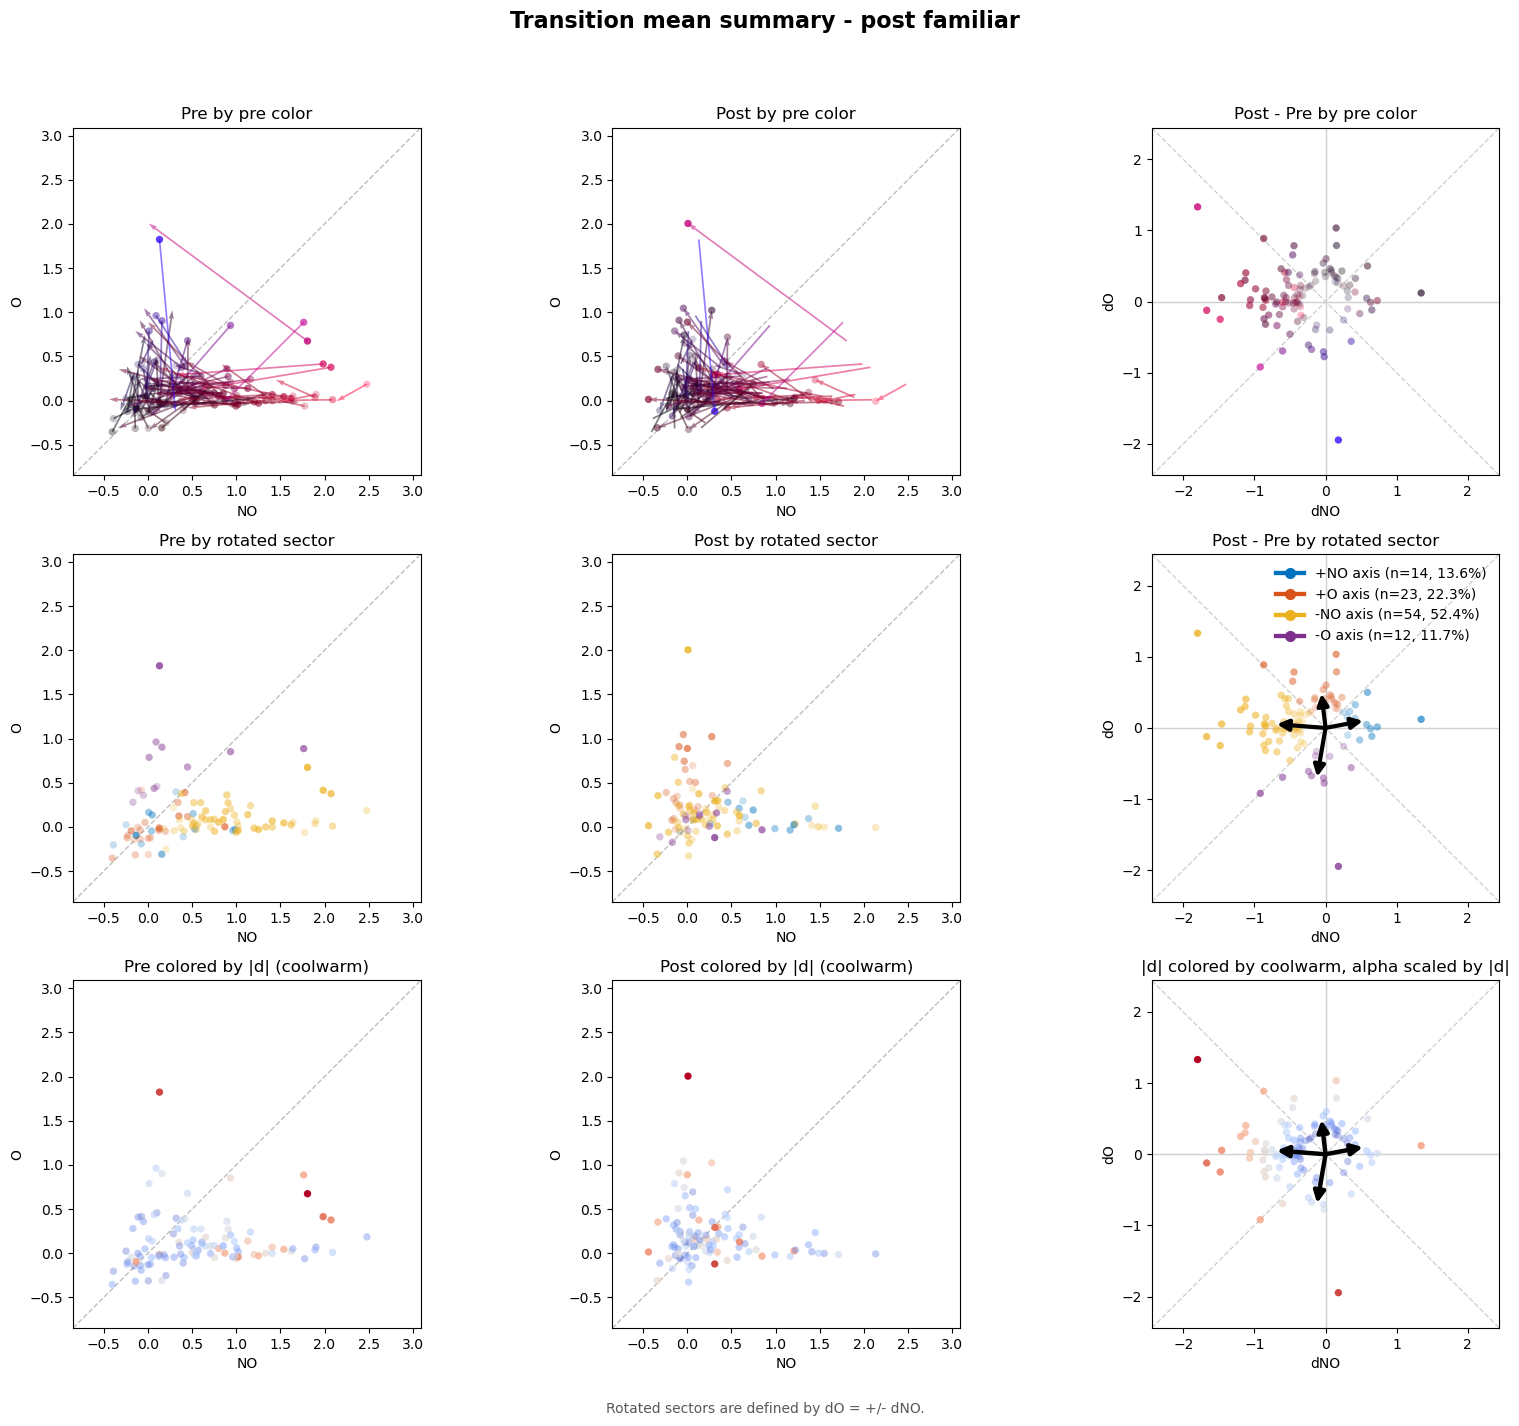

In [18]:
post_familiar_mean = post_familiar_mean.loc[post_familiar_mean['dNorm'] > 0.3]

_ = plot_mean_transition_summary(
    post_familiar_mean,
    title="Transition mean summary - post familiar",
    start_label="Pre",
    end_label="Post",
    response_lims=post_response_lims,
    shift_lims=post_shift_lims,
    style=PLOT_STYLE,
)


## Post mean: novel


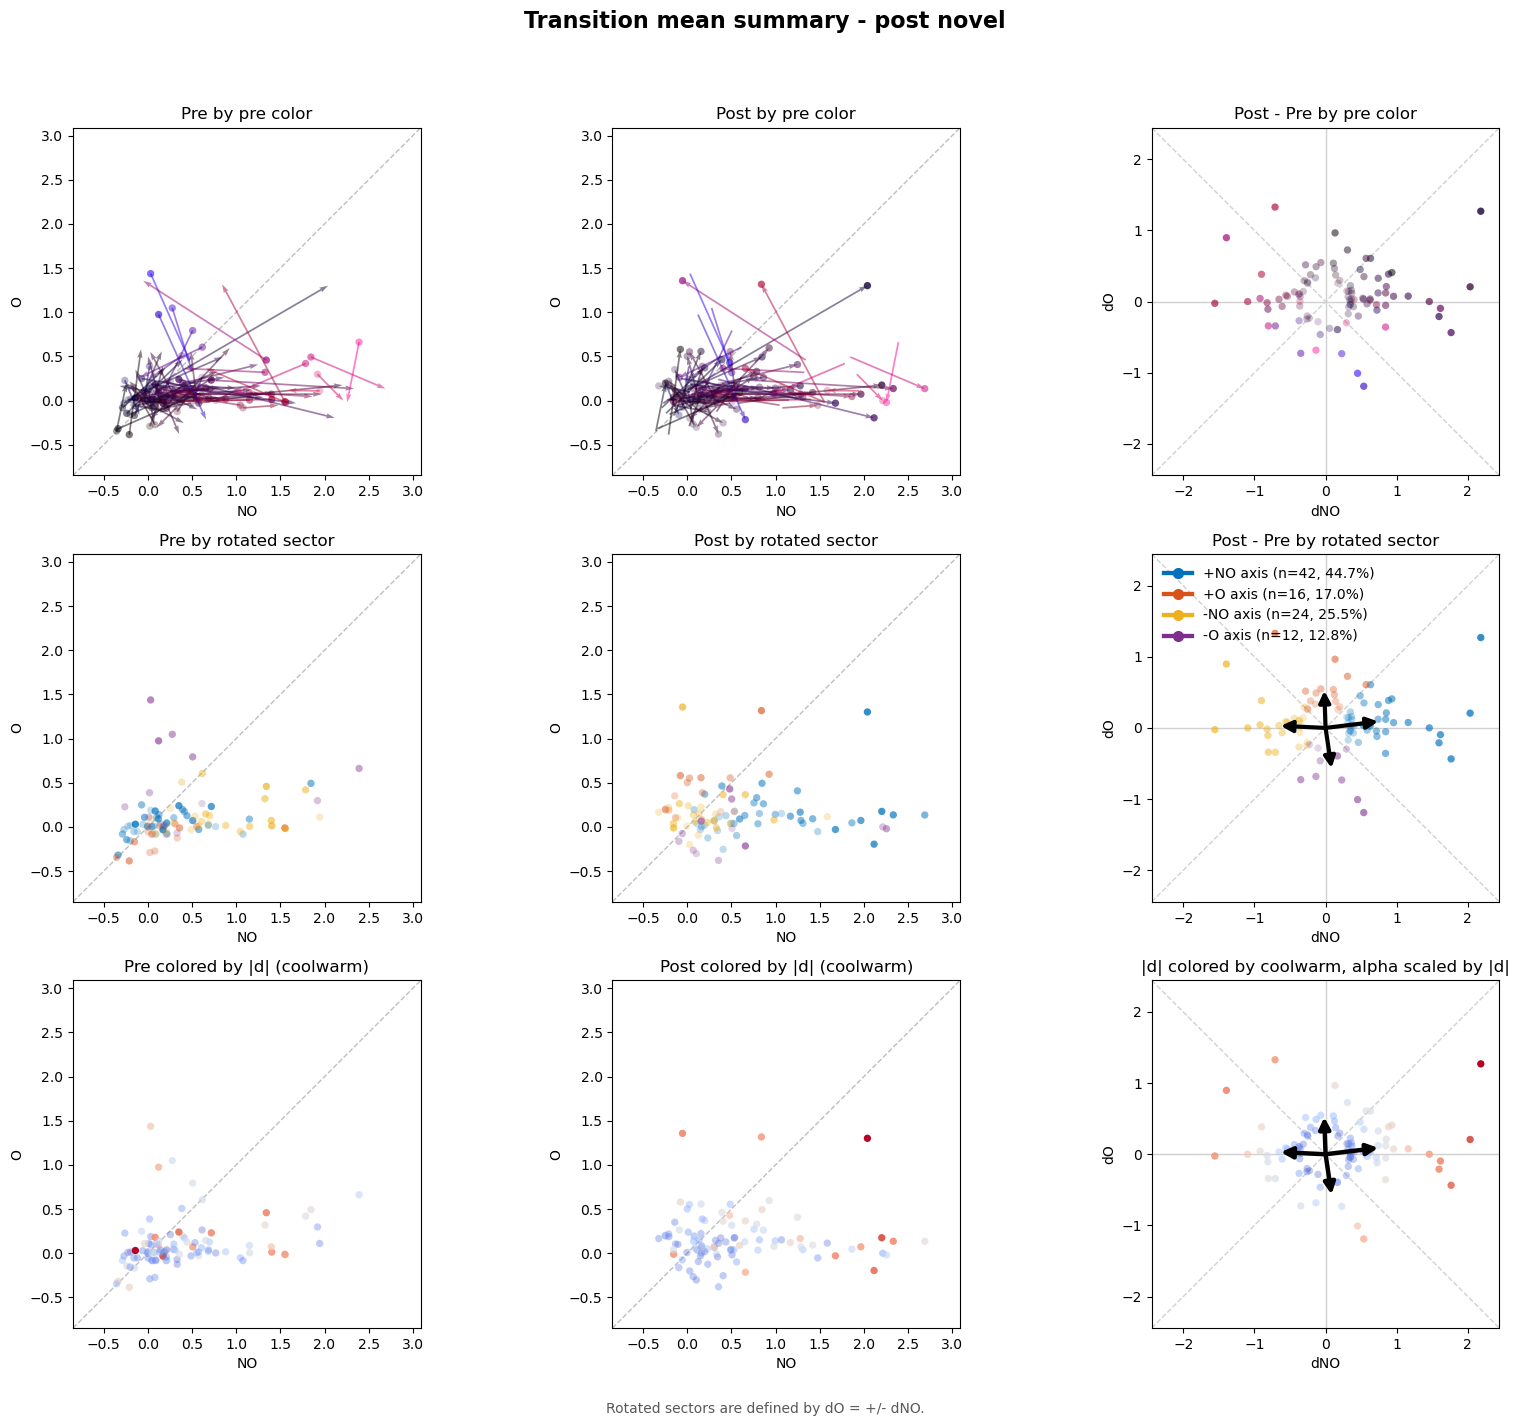

In [19]:
post_novel_mean = post_novel_mean.loc[post_novel_mean['dNorm'] > 0.3]

_ = plot_mean_transition_summary(
    post_novel_mean,
    title="Transition mean summary - post novel",
    start_label="Pre",
    end_label="Post",
    response_lims=post_response_lims,
    shift_lims=post_shift_lims,
    style=PLOT_STYLE,
)


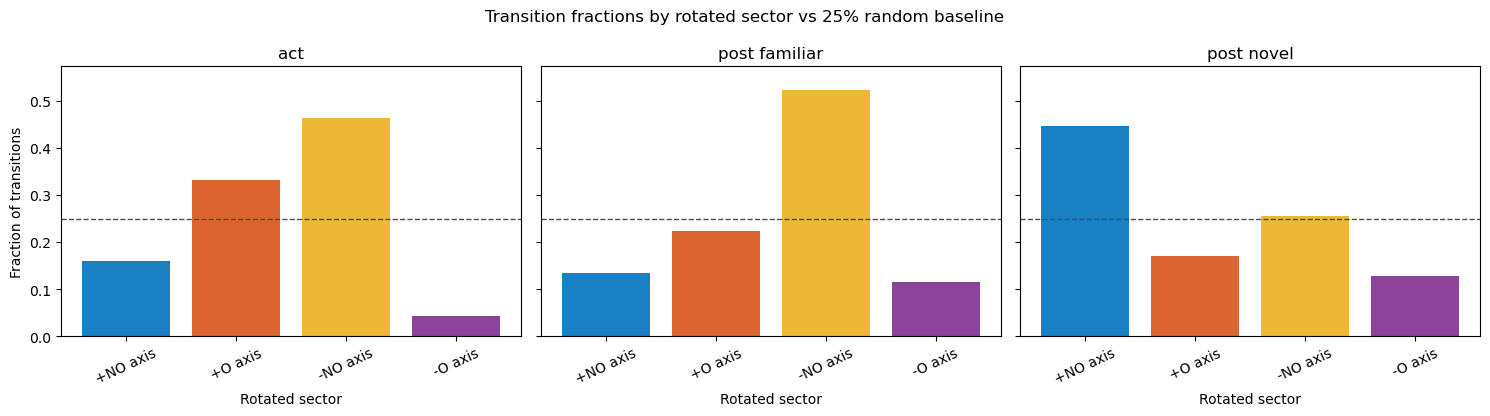

In [20]:
import matplotlib.pyplot as plt

fraction_tables = {
    "act": th.sector_fraction_table(act_mean),
    "post familiar": th.sector_fraction_table(post_familiar_mean),
    "post novel": th.sector_fraction_table(post_novel_mean),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (label, table) in zip(axes, fraction_tables.items()):
    colors = [th.ROTATED_SECTOR_PALETTE[sector] for sector in table["RotatedSector"]]
    ax.bar(table["RotatedSector"], table["Fraction"], color=colors, alpha=0.9)
    ax.axhline(0.25, color="0.3", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_ylim(0, max(0.35, float(max(tbl["Fraction"].max() for tbl in fraction_tables.values())) + 0.05))
    ax.tick_params(axis="x", rotation=25)
    ax.set_xlabel("Rotated sector")
axes[0].set_ylabel("Fraction of transitions")
fig.suptitle("Transition fractions by rotated sector vs 25% random baseline")
fig.tight_layout()
